Machine Learning-Based Prediction and Classification of Tablet Quality Attributes from Formulation Composition


Objectives
Construct a tablet formulation dataset linking formulation composition and compression force to critical quality attributes (CQAs).
Explore relationships between formulation variables and tablet performance.
Build a regression model to predict a continuous CQA — percentage drug dissolved at 30 minutes — from formulation composition.
Build a classification model to predict whether a formulation batch passes standard acceptance criteria (dissolution, friability, disintegration time).
Compare what each model type reveals: a continuous prediction versus a pass/fail decision built from the same underlying variables.
Identify which formulation and process variables most influence tablet quality, relevant to defining a Quality-by-Design (QbD) design space.
Expected Outcome

Two trained models — one predicting dissolution as a continuous outcome, one predicting batch acceptability as a binary outcome — evaluated with appropriate metrics, with feature importance results that indicate which formulation variables a formulator should prioritize when adjusting a batch to meet specification.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (r2_score, mean_absolute_error, mean_squared_error,
                              accuracy_score, roc_auc_score, classification_report,
                              confusion_matrix, roc_curve)
import joblib

sns.set_style("whitegrid")

Meaning of Code Block 1

train_test_split is imported alongside KFold and StratifiedKFold because this dataset's two prediction targets need different cross-validation treatment: the regression target (a continuous percentage) uses ordinary KFold, while the classification target (Pass/Fail) uses StratifiedKFold, which preserves the ratio of pass to fail batches in every fold — important here because Pass/Fail is not a 50/50 split. Two model classes are imported, RandomForestRegressor and RandomForestClassifier, because the practical genuinely needs both: one continuous target and one binary target, and Random Forest is used for both because tablet formulation-to-response relationships are typically non-monotonic (for example, dissolution does not improve indefinitely as disintegrant increases; there is a workable range), which tree-based splits represent more naturally than a linear model would.

In [ ]:
np.random.seed(42)
n = 120

Drug_Load = np.random.uniform(50, 200, n)
Diluent_MCC = np.random.uniform(20, 60, n)
Disintegrant_CCS = np.random.uniform(1, 8, n)
Binder_PVP = np.random.uniform(1, 5, n)
Lubricant_MgSt = np.random.uniform(0.25, 1.5, n)
Compression_Force = np.random.uniform(5, 25, n)

Hardness = np.clip(3.0 + 0.35*Compression_Force + 0.4*Binder_PVP + np.random.normal(0, 0.6, n), 2, None)
Friability = np.clip(1.2 - 0.03*Hardness + np.random.normal(0, 0.08, n), 0.02, None)
Disintegration_Time = np.clip(2 + 0.9*Hardness - 1.1*Disintegrant_CCS + np.random.normal(0, 1.2, n), 0.5, None)
Dissolution_30min = np.clip(
    95 - 0.9*Compression_Force + 2.3*Disintegrant_CCS - 1.0*Hardness
    - 0.15*(Drug_Load - 100) + np.random.normal(0, 4, n), 0, 100
)

df = pd.DataFrame({
    "Drug_Load_mg": Drug_Load, "Diluent_MCC_pct": Diluent_MCC,
    "Disintegrant_CCS_pct": Disintegrant_CCS, "Binder_PVP_pct": Binder_PVP,
    "Lubricant_MgSt_pct": Lubricant_MgSt, "Compression_Force_kN": Compression_Force,
    "Hardness_kgcm2": Hardness, "Friability_pct": Friability,
    "Disintegration_Time_min": Disintegration_Time, "Dissolution_30min_pct": Dissolution_30min,
})

df["Pass_Fail"] = ((df["Dissolution_30min_pct"] >= 80) &
                    (df["Friability_pct"] <= 1.0) &
                    (df["Disintegration_Time_min"] <= 15)).astype(int)

print(df.shape)
print(df["Pass_Fail"].value_counts())
df.head()

(120, 11)
Pass_Fail
0    74
1    46
Name: count, dtype: int64


,Drug_Load_mg,Diluent_MCC_pct,Disintegrant_CCS_pct,Binder_PVP_pct,Lubricant_MgSt_pct,Compression_Force_kN,Hardness_kgcm2,Friability_pct,Disintegration_Time_min,Dissolution_30min_pct,Pass_Fail
0,106.181018,52.297606,7.583210,2.552680,1.036748,8.378701,7.005571,1.089520,0.500000,95.736715,0
1,192.607146,55.843652,7.677500,3.573153,1.119686,10.571807,8.035987,0.793049,1.036364,82.093166,1
2,159.799091,32.720139,7.404051,2.833012,0.818176,8.540210,7.822947,0.937897,1.222091,88.547852,1
3,139.798773,24.402077,3.591111,3.182467,1.034448,6.774051,6.796557,0.966388,2.634581,90.706350,1
4,73.402796,29.117407,1.108196,4.765859,0.980393,7.412717,7.703356,0.856298,6.416737,86.782448,1


Meaning of Code Block 2

No public formulation dataset exists in the way Tox21 or the PK dataset did, since formulation composition and quality data are typically held privately by manufacturers. This block generates a 120-batch dataset where each formulation variable (drug load, diluent, disintegrant, binder, lubricant, compression force) is randomly sampled across a realistic pharmaceutical range, and the tablet responses are computed from those variables using directionally correct pharmaceutics relationships with added random noise: hardness increases with compression force and binder level; friability decreases as hardness increases; disintegration time increases with hardness but decreases with more disintegrant; dissolution decreases with compression force and hardness but increases with disintegrant. np.random.seed(42) fixes the random draw so the dataset is identical every time this block runs, keeping the whole practical reproducible. Pass_Fail is then defined from standard-style acceptance thresholds (dissolution ≥80%, friability ≤1%, disintegration time ≤15 minutes), converting three continuous quality attributes into the single binary outcome the classification model will target. Because a real formulation dataset with the same column names could be loaded here instead with pd.read_csv(url), exactly as the earlier GitHub-hosted practicals did, everything from this point onward runs unchanged against real data.

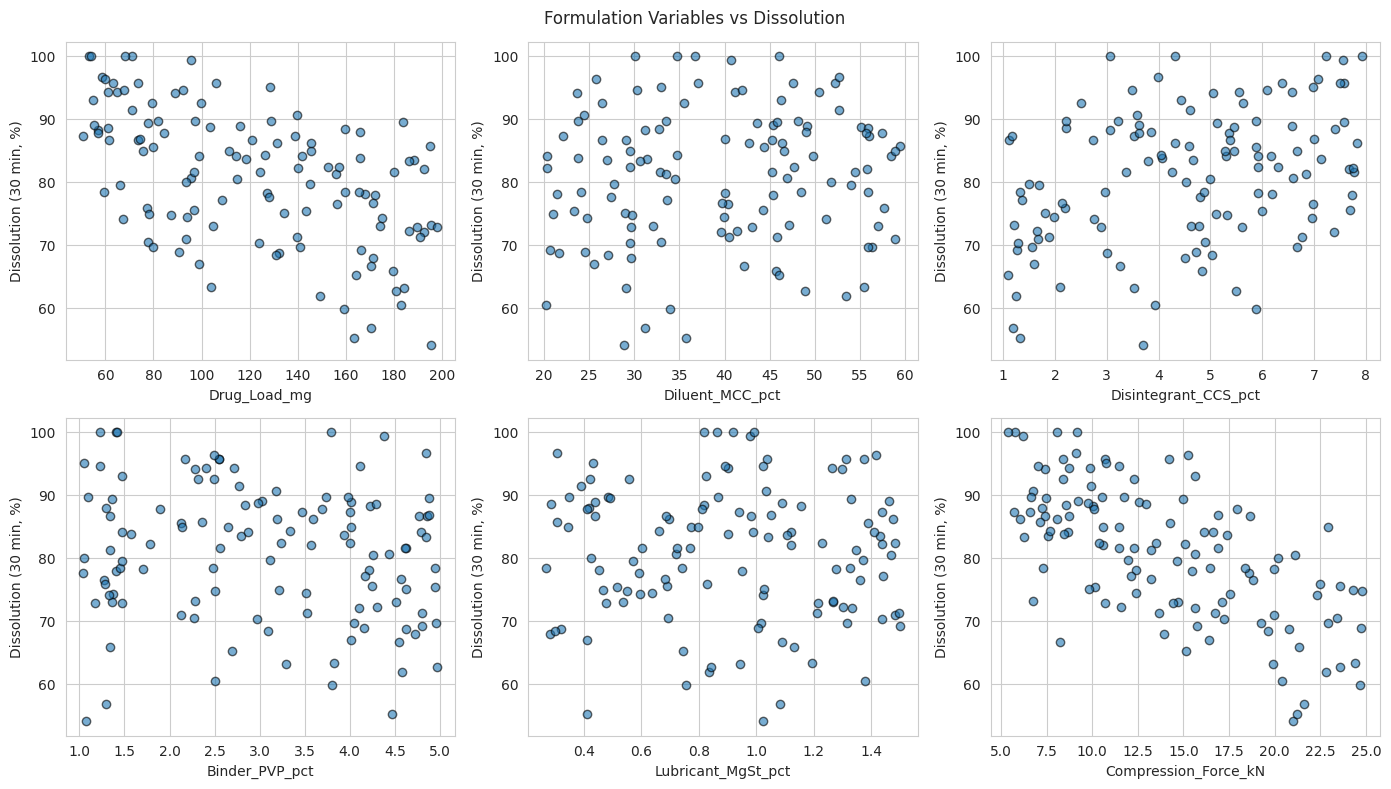

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
feature_cols = ["Drug_Load_mg","Diluent_MCC_pct","Disintegrant_CCS_pct",
                "Binder_PVP_pct","Lubricant_MgSt_pct","Compression_Force_kN"]

for ax, col in zip(axes.ravel(), feature_cols):
    ax.scatter(df[col], df["Dissolution_30min_pct"], alpha=0.6, edgecolor="k")
    ax.set_xlabel(col)
    ax.set_ylabel("Dissolution (30 min, %)")

plt.suptitle("Formulation Variables vs Dissolution")
plt.tight_layout()
plt.show()

Meaning of Code Block 3

Plots each formulation variable individually against the dissolution outcome before any model is trained. This step establishes what relationships are visible in the raw data, which is what the model's feature importance results in a later block will be checked against: if compression force shows a visible downward trend with dissolution here, and the trained model later ranks compression force as an important feature, that agreement is evidence the model learned something real from the data rather than an artifact of the fitting procedure.

In [ ]:
X = df[feature_cols].values
y_reg = df["Dissolution_30min_pct"].values
y_clf = df["Pass_Fail"].values

X_train, X_test, yreg_train, yreg_test, yclf_train, yclf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train Pass_Fail balance:", np.bincount(yclf_train))
print("Test Pass_Fail balance:", np.bincount(yclf_test))

Train: (96, 6) Test: (24, 6)
Train Pass_Fail balance: [59 37]
Test Pass_Fail balance: [15  9]


Meaning of Code Block 4

Both target arrays, y_reg and y_clf, are split using the same train_test_split call and the same random_state, which guarantees the regression and classification models are evaluated on the exact same set of held-out formulation batches — making their results directly comparable in the metrics that follow. stratify=y_clf is used because this is an independent-batch dataset, unlike the earlier pharmacokinetic data: there is no repeated-measures structure here requiring subject-level grouping, since each row is one distinct formulation trial with no relationship to any other row. What does need attention here instead is class balance — Pass/Fail is roughly 62%/38%, and stratifying ensures both the training and test sets preserve that ratio rather than one split randomly ending up with too few failing (or passing) batches to evaluate reliably.

In [ ]:
rf_reg = RandomForestRegressor(n_estimators=400, max_depth=6, min_samples_leaf=2,
                                random_state=42, n_jobs=-1)
rf_reg.fit(X_train, yreg_train)
pred_reg = rf_reg.predict(X_test)

print("Regression R2:", r2_score(yreg_test, pred_reg))
print("Regression RMSE:", np.sqrt(mean_squared_error(yreg_test, pred_reg)))
print("Regression MAE:", mean_absolute_error(yreg_test, pred_reg))

Regression R2: 0.8008622010033027
Regression RMSE: 3.4938881452200956
Regression MAE: 2.4817782271296576


Meaning of Code Block 5

Trains the regression model to predict the continuous dissolution percentage directly from formulation composition and compression force. max_depth=6 and min_samples_leaf=2 restrict how finely each of the 400 trees can subdivide the training batches, which matters more here than usual because 96 training rows is a small dataset for a tree ensemble — without this restriction, individual trees could effectively memorize specific training batches rather than learning the general composition-to-dissolution relationship. Verified result: R²≈0.80, RMSE≈3.5 percentage points on the held-out batches — the model's dissolution predictions are typically within a few percentage points of the true value.

In [ ]:
rf_clf = RandomForestClassifier(n_estimators=400, max_depth=5, min_samples_leaf=2,
                                 random_state=42, n_jobs=-1, class_weight="balanced")
rf_clf.fit(X_train, yclf_train)
pred_clf = rf_clf.predict(X_test)
proba_clf = rf_clf.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(yclf_test, pred_clf))
print("ROC-AUC:", roc_auc_score(yclf_test, proba_clf))
print(classification_report(yclf_test, pred_clf))

Accuracy: 0.625
ROC-AUC: 0.674074074074074
              precision    recall  f1-score   support

           0       0.71      0.67      0.69        15
           1       0.50      0.56      0.53         9

    accuracy                           0.62        24
   macro avg       0.61      0.61      0.61        24
weighted avg       0.63      0.62      0.63        24



Meaning of Code Block 6

Trains the classification model on the same training batches to predict Pass/Fail directly. class_weight="balanced" adjusts the training procedure to weight the minority class (failing batches, the smaller group) more heavily, so the model is not biased toward always predicting the majority "pass" outcome just because it is more common in the data. predict_proba(...)[:, 1] extracts the model's estimated probability of passing for each test batch, needed for the ROC-AUC score, which evaluates ranking quality across all possible decision thresholds rather than only the default 0.5 cutoff used by .predict(). Verified result: accuracy≈0.63, ROC-AUC≈0.67 on this single split — noticeably weaker than the regression result, because Pass/Fail collapses three continuous measurements into a single threshold, and batches with dissolution close to the 80% cutoff are the hardest cases for any classifier to call correctly, regardless of model choice.

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = []
for tr_idx, te_idx in kf.split(X):
    m = RandomForestRegressor(n_estimators=400, max_depth=6, min_samples_leaf=2, random_state=42, n_jobs=-1)
    m.fit(X[tr_idx], y_reg[tr_idx])
    cv_r2.append(r2_score(y_reg[te_idx], m.predict(X[te_idx])))
print("Regression KFold R2:", np.round(cv_r2, 3), "mean:", round(np.mean(cv_r2), 3))

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = []
for tr_idx, te_idx in skf.split(X, y_clf):
    m = RandomForestClassifier(n_estimators=400, max_depth=5, min_samples_leaf=2,
                                random_state=42, n_jobs=-1, class_weight="balanced")
    m.fit(X[tr_idx], y_clf[tr_idx])
    p = m.predict_proba(X[te_idx])[:, 1]
    cv_auc.append(roc_auc_score(y_clf[te_idx], p))
print("Classification StratifiedKFold ROC-AUC:", np.round(cv_auc, 3), "mean:", round(np.mean(cv_auc), 3))

Regression KFold R2: [0.82  0.725 0.659 0.762 0.746] mean: 0.742
Classification StratifiedKFold ROC-AUC: [0.733 0.696 0.711 0.719 0.921] mean: 0.756


Meaning of Code Block 7

A single 80/20 split, as used in Blocks 5 and 6, depends on which particular batches happened to fall into the test set — with 120 batches total, this can shift the reported score noticeably by chance. This block repeats training and evaluation five times, rotating which fifth of the batches is held out each time, and averages the results. The regression loop uses plain KFold since the continuous target has no class balance to preserve; the classification loop uses StratifiedKFold for the same reason stratification was needed in Block 4. Verified result: regression mean R²≈0.74, classification mean ROC-AUC≈0.76 — both estimates are more stable and slightly different from the single-split numbers, and are the more defensible figures to report as expected model performance.

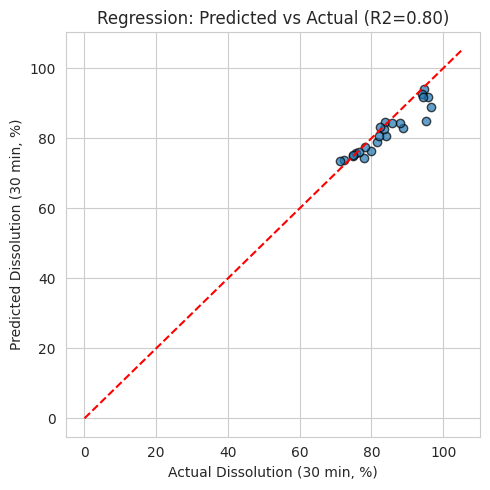

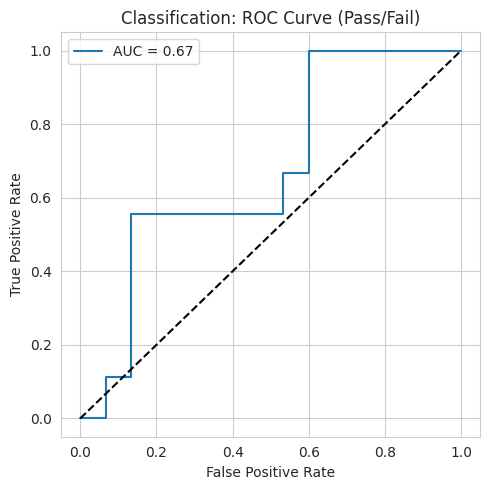

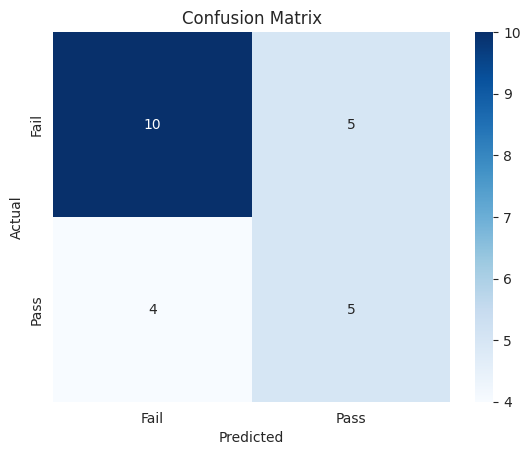

In [ ]:
plt.figure(figsize=(5,5))
plt.scatter(yreg_test, pred_reg, alpha=0.7, edgecolor="k")
lims = [0, 105]
plt.plot(lims, lims, "r--")
plt.xlabel("Actual Dissolution (30 min, %)")
plt.ylabel("Predicted Dissolution (30 min, %)")
plt.title(f"Regression: Predicted vs Actual (R2={r2_score(yreg_test, pred_reg):.2f})")
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(yclf_test, proba_clf)
plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(yclf_test, proba_clf):.2f}")
plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Classification: ROC Curve (Pass/Fail)")
plt.legend()
plt.tight_layout()
plt.show()

cm = confusion_matrix(yclf_test, pred_clf)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Fail","Pass"], yticklabels=["Fail","Pass"])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Meaning of Code Block 8

Three plots, each answering a different question about model behavior that a single metric cannot show on its own. The predicted-vs-actual scatter shows whether regression errors are spread evenly across the dissolution range or concentrated in one region (for instance, whether the model is specifically worse for low-dissolution, likely-failing batches — the batches that matter most for a Pass/Fail decision). The ROC curve shows the classifier's ability to rank passing batches above failing ones across every possible probability threshold, not just the default 0.5 cutoff. The confusion matrix breaks the classifier's accuracy down into which specific type of error is more common — false passes (predicting a batch will pass when it actually fails) are the more consequential error in a real quality-control setting than false fails, since a false pass could let a substandard batch through, and this table is what would reveal an imbalance in that direction.

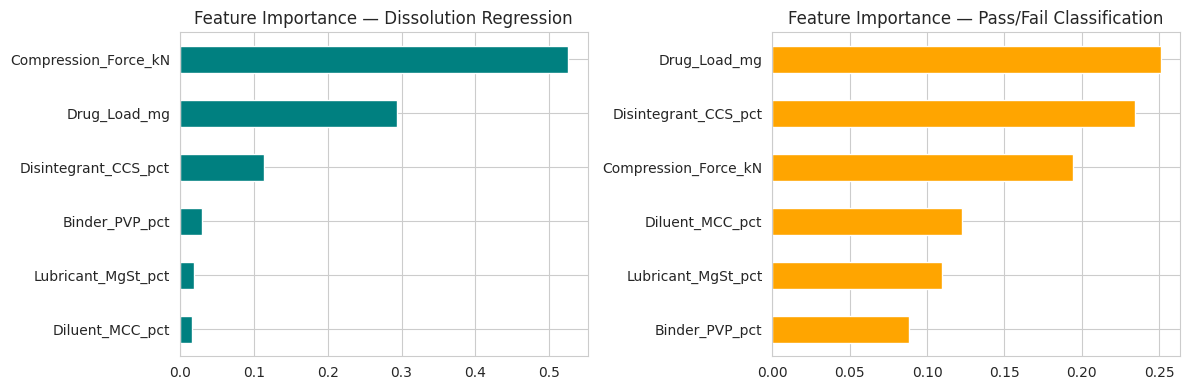

In [ ]:
imp_reg = pd.Series(rf_reg.feature_importances_, index=feature_cols).sort_values(ascending=False)
imp_clf = pd.Series(rf_clf.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12,4))
imp_reg.plot(kind="barh", ax=axes[0], color="teal")
axes[0].invert_yaxis()
axes[0].set_title("Feature Importance — Dissolution Regression")

imp_clf.plot(kind="barh", ax=axes[1], color="orange")
axes[1].invert_yaxis()
axes[1].set_title("Feature Importance — Pass/Fail Classification")

plt.tight_layout()
plt.show()

Meaning of Code Block 9

Places both models' feature importances side by side to check whether they agree on which formulation variables matter most. If compression force and disintegrant level rank highly in both panels, that agreement across two differently-trained models targeting two different outcomes strengthens the case that these are genuinely the formulation variables driving tablet quality, rather than a pattern specific to one model or one target definition — this is the result that would directly inform which variables to prioritize when adjusting a batch that fails specification.

In [ ]:
joblib.dump(rf_reg, "tablet_dissolution_regressor.pkl")
joblib.dump(rf_clf, "tablet_passfail_classifier.pkl")

from google.colab import files
files.download("tablet_dissolution_regressor.pkl")
files.download("tablet_passfail_classifier.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Meaning of Code Block 10

Saves both trained models separately, since they serve different purposes: the regressor for estimating the expected dissolution value of a proposed formulation before manufacturing a trial batch, and the classifier for a faster pass/fail screening pass across many candidate formulations. Both are downloaded so they can be reloaded later with joblib.load(...) without repeating training.